## PINN Surrogate

In [1]:
# imports
from __future__ import annotations
import json, math
from pathlib import Path
from typing import Literal
import numpy as np
import torch
import torch.nn as nn
from pydantic import BaseModel, Field
import matplotlib.pyplot as plt
from matplotlib import animation

torch.set_default_dtype(torch.float32)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Couldn't import dot_parser, loading of dot files will not be possible.
Device: cpu


In [2]:
class DomainConfig(BaseModel):
    x_min: float = 0.0
    x_max: float = 1.0
    y_min: float = 0.0
    y_max: float = 1.0
    t_min: float = 0.0
    t_max: float = 0.1

class PhysicsConfig(BaseModel):
    alpha: float = 1.0
    hotspot_center: tuple[float, float] = (0.5, 0.5)
    hotspot_sigma: float = 0.1
    hotspot_amp: float = 1.0

class FDConfig(BaseModel):
    nx: int = 81
    ny: int = 81
    nt: int = 4001

class PINNConfig(BaseModel):
    hidden_dim: int = 64
    n_hidden: int = 5
    activation: Literal["tanh", "sin"] = "tanh"

class TrainConfig(BaseModel):
    n_ic: int = 2000
    n_bc: int = 2000
    n_pde: int = 10000
    n_iters: int = 8000
    lr: float = 1e-3
    w_ic: float = 100.0
    w_bc: float = 100.0
    w_pde: float = 1.0
    log_every: int = 500
    seed: int = 0

DOMAIN = DomainConfig()
PHYSICS = PhysicsConfig()
FD = FDConfig()
PINN_CFG = PINNConfig()
TRAIN = TrainConfig()

In [3]:
# ground-truth solver
def initial_condition(X: np.ndarray, Y: np.ndarray, p: PhysicsConfig) -> np.ndarray:
    cx, cy = p.hotspot_center
    return p.hotspot_amp * np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * p.hotspot_sigma ** 2))

def solve_fd(domain: DomainConfig, physics: PhysicsConfig, fd: FDConfig) -> dict:
    x = np.linspace(domain.x_min, domain.x_max, fd.nx)
    y = np.linspace(domain.y_min, domain.y_max, fd.ny)
    t = np.linspace(domain.t_min, domain.t_max, fd.nt)
    dx, dy, dt = x[1] - x[0], y[1] - y[0], t[1] - t[0]
    cfl = physics.alpha * dt * (1 / dx**2 + 1 / dy**2)
    assert cfl <= 0.5, f"CFL violated: {cfl:.3f}"

    X, Y = np.meshgrid(x, y, indexing="ij")
    u = initial_condition(X, Y, physics).astype(np.float32)
    u[0, :] = u[-1, :] = u[:, 0] = u[:, -1] = 0.0

    snaps = [u.copy()]
    save_idxs = np.linspace(0, fd.nt - 1, 41, dtype=int)
    save_set = set(save_idxs.tolist())
    rx = physics.alpha * dt / dx**2
    ry = physics.alpha * dt / dy**2

    for n in range(1, fd.nt):
        un = u.copy()
        u[1:-1, 1:-1] = (un[1:-1, 1:-1]
                        + rx * (un[2:, 1:-1] - 2 * un[1:-1, 1:-1] + un[:-2, 1:-1])
                        + ry * (un[1:-1, 2:] - 2 * un[1:-1, 1:-1] + un[1:-1, :-2]))
        if n in save_set:
            snaps.append(u.copy())

    return {
        "x": x, "y": y,
        "t_snaps": t[save_idxs],
        "u_snaps": np.stack(snaps, axis=0),  # (T, nx, ny)
    }

gt = solve_fd(DOMAIN, PHYSICS, FD)
print("snapshots:", gt["u_snaps"].shape, "t range:", gt["t_snaps"][0], "->", gt["t_snaps"][-1])

snapshots: (41, 81, 81) t range: 0.0 -> 0.1


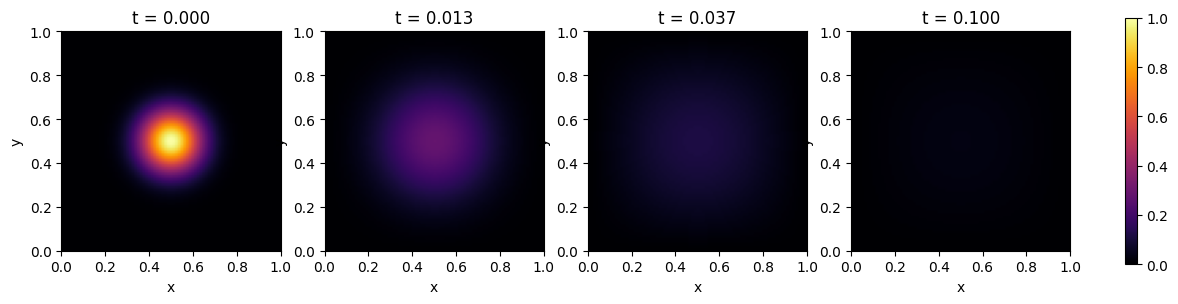

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for ax, idx in zip(axes, [0, 5, 15, 40]):
    im = ax.imshow(gt["u_snaps"][idx].T, origin="lower",
                   extent=[DOMAIN.x_min, DOMAIN.x_max, DOMAIN.y_min, DOMAIN.y_max],
                   vmin=0, vmax=PHYSICS.hotspot_amp, cmap="inferno")
    ax.set_title(f"t = {gt['t_snaps'][idx]:.3f}")
    ax.set_xlabel("x"); ax.set_ylabel("y")
fig.colorbar(im, ax=axes, fraction=0.02)
plt.show()

In [6]:
class PINN(nn.Module):
    def __init__(self, cfg: PINNConfig):
        super().__init__()
        act = nn.Tanh() if cfg.activation == "tanh" else nn.SiLU()
        layers: list[nn.Module] = [nn.Linear(3, cfg.hidden_dim), act]
        for _ in range(cfg.n_hidden - 1):
            layers += [nn.Linear(cfg.hidden_dim, cfg.hidden_dim), act]
        layers += [nn.Linear(cfg.hidden_dim, 1)]
        self.net = nn.Sequential(*layers)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor, y: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        return self.net(torch.cat([x, y, t], dim=-1))

In [7]:
def sample_pde(n: int, d: DomainConfig) -> tuple[torch.Tensor, ...]:
    x = torch.rand(n, 1, device=DEVICE) * (d.x_max - d.x_min) + d.x_min
    y = torch.rand(n, 1, device=DEVICE) * (d.y_max - d.y_min) + d.y_min
    t = torch.rand(n, 1, device=DEVICE) * (d.t_max - d.t_min) + d.t_min
    return x.requires_grad_(True), y.requires_grad_(True), t.requires_grad_(True)

def sample_ic(n: int, d: DomainConfig, p: PhysicsConfig) -> tuple[torch.Tensor, ...]:
    x = torch.rand(n, 1, device=DEVICE) * (d.x_max - d.x_min) + d.x_min
    y = torch.rand(n, 1, device=DEVICE) * (d.y_max - d.y_min) + d.y_min
    t = torch.full_like(x, d.t_min)
    cx, cy = p.hotspot_center
    u0 = p.hotspot_amp * torch.exp(-((x - cx) ** 2 + (y - cy) ** 2) / (2 * p.hotspot_sigma ** 2))
    return x, y, t, u0

def sample_bc(n: int, d: DomainConfig) -> tuple[torch.Tensor, ...]:
    n_per = n // 4
    t = torch.rand(n_per * 4, 1, device=DEVICE) * (d.t_max - d.t_min) + d.t_min
    s = torch.rand(n_per, 1, device=DEVICE)
    x = torch.cat([torch.full_like(s, d.x_min),
                   torch.full_like(s, d.x_max),
                   s * (d.x_max - d.x_min) + d.x_min,
                   s * (d.x_max - d.x_min) + d.x_min], dim=0)
    y = torch.cat([s * (d.y_max - d.y_min) + d.y_min,
                   s * (d.y_max - d.y_min) + d.y_min,
                   torch.full_like(s, d.y_min),
                   torch.full_like(s, d.y_max)], dim=0)
    return x, y, t

In [8]:
# pde residual + losses
def pde_residual(model: PINN, x: torch.Tensor, y: torch.Tensor, t: torch.Tensor,
                 alpha: float) -> torch.Tensor:
    u = model(x, y, t)
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, torch.ones_like(u_y), create_graph=True)[0]
    return u_t - alpha * (u_xx + u_yy)

In [9]:
# train
torch.manual_seed(TRAIN.seed); np.random.seed(TRAIN.seed)
model = PINN(PINN_CFG).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=TRAIN.lr)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=TRAIN.n_iters)
history: list[dict] = []

for it in range(TRAIN.n_iters):
    opt.zero_grad()

    x_p, y_p, t_p = sample_pde(TRAIN.n_pde, DOMAIN)
    res = pde_residual(model, x_p, y_p, t_p, PHYSICS.alpha)
    loss_pde = (res ** 2).mean()

    x_i, y_i, t_i, u_i = sample_ic(TRAIN.n_ic, DOMAIN, PHYSICS)
    loss_ic = ((model(x_i, y_i, t_i) - u_i) ** 2).mean()

    x_b, y_b, t_b = sample_bc(TRAIN.n_bc, DOMAIN)
    loss_bc = (model(x_b, y_b, t_b) ** 2).mean()

    loss = TRAIN.w_pde * loss_pde + TRAIN.w_ic * loss_ic + TRAIN.w_bc * loss_bc
    loss.backward()
    opt.step(); sched.step()

    if it % TRAIN.log_every == 0 or it == TRAIN.n_iters - 1:
        history.append(dict(it=it, total=loss.item(), pde=loss_pde.item(),
                            ic=loss_ic.item(), bc=loss_bc.item()))
        print(f"[{it:5d}] total={loss.item():.4e}  pde={loss_pde.item():.4e}  "
              f"ic={loss_ic.item():.4e}  bc={loss_bc.item():.4e}")

[    0] total=2.7793e+00  pde=1.4099e-04  ic=2.3967e-02  bc=3.8251e-03
[  500] total=2.4577e+00  pde=9.9722e-02  ic=2.2955e-02  bc=6.2500e-04
[ 1000] total=1.7909e+00  pde=1.3079e-01  ic=1.6243e-02  bc=3.5805e-04
[ 1500] total=6.7498e-01  pde=1.2925e-01  ic=5.3458e-03  bc=1.1146e-04
[ 2000] total=2.7839e-01  pde=1.3293e-01  ic=1.1757e-03  bc=2.7890e-04
[ 2500] total=9.1892e-02  pde=3.7835e-02  ic=5.0138e-04  bc=3.9184e-05
[ 3000] total=7.3995e-02  pde=2.9927e-02  ic=4.0498e-04  bc=3.5698e-05
[ 3500] total=4.1110e-02  pde=2.6651e-02  ic=1.1755e-04  bc=2.7046e-05
[ 4000] total=4.2401e-02  pde=2.8012e-02  ic=1.1560e-04  bc=2.8296e-05
[ 4500] total=2.7755e-02  pde=2.0603e-02  ic=4.7794e-05  bc=2.3717e-05
[ 5000] total=2.4815e-02  pde=1.8287e-02  ic=4.2160e-05  bc=2.3115e-05
[ 5500] total=2.2026e-02  pde=1.6078e-02  ic=3.6065e-05  bc=2.3419e-05
[ 6000] total=1.7131e-02  pde=1.1076e-02  ic=3.4488e-05  bc=2.6067e-05
[ 6500] total=1.6193e-02  pde=1.0212e-02  ic=3.9588e-05  bc=2.0224e-05
[ 7000

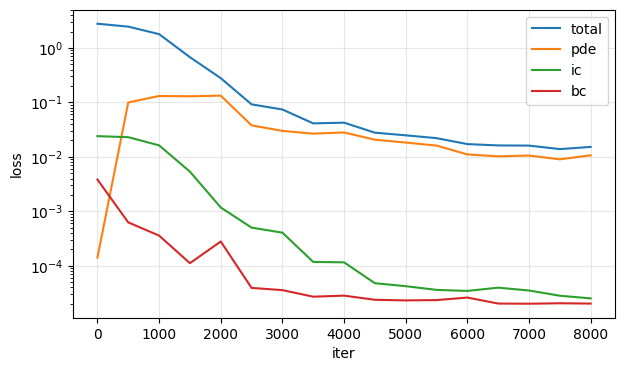

In [10]:
# loss curves
fig, ax = plt.subplots(figsize=(7, 4))
its = [h["it"] for h in history]
for k in ["total", "pde", "ic", "bc"]:
    ax.semilogy(its, [h[k] for h in history], label=k)
ax.set_xlabel("iter"); ax.set_ylabel("loss"); ax.legend(); ax.grid(alpha=0.3)
plt.show()

In [11]:
# evaluate on the same grid + times as the FD solver
@torch.no_grad()
def predict_grid(model: PINN, x: np.ndarray, y: np.ndarray, t_vals: np.ndarray) -> np.ndarray:
    model.eval()
    X, Y = np.meshgrid(x, y, indexing="ij")
    out = np.empty((len(t_vals), len(x), len(y)), dtype=np.float32)
    xb = torch.tensor(X.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
    yb = torch.tensor(Y.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
    for i, tv in enumerate(t_vals):
        tb = torch.full_like(xb, float(tv))
        u = model(xb, yb, tb).cpu().numpy().reshape(len(x), len(y))
        out[i] = u
    return out

u_pred = predict_grid(model, gt["x"], gt["y"], gt["t_snaps"])
u_true = gt["u_snaps"]
err = u_pred - u_true
rmse = float(np.sqrt(np.mean(err ** 2)))
rel = float(np.linalg.norm(err) / np.linalg.norm(u_true))
print(f"RMSE = {rmse:.4e}   relative L2 = {rel:.4e}")

RMSE = 2.8038e-03   relative L2 = 4.3392e-02


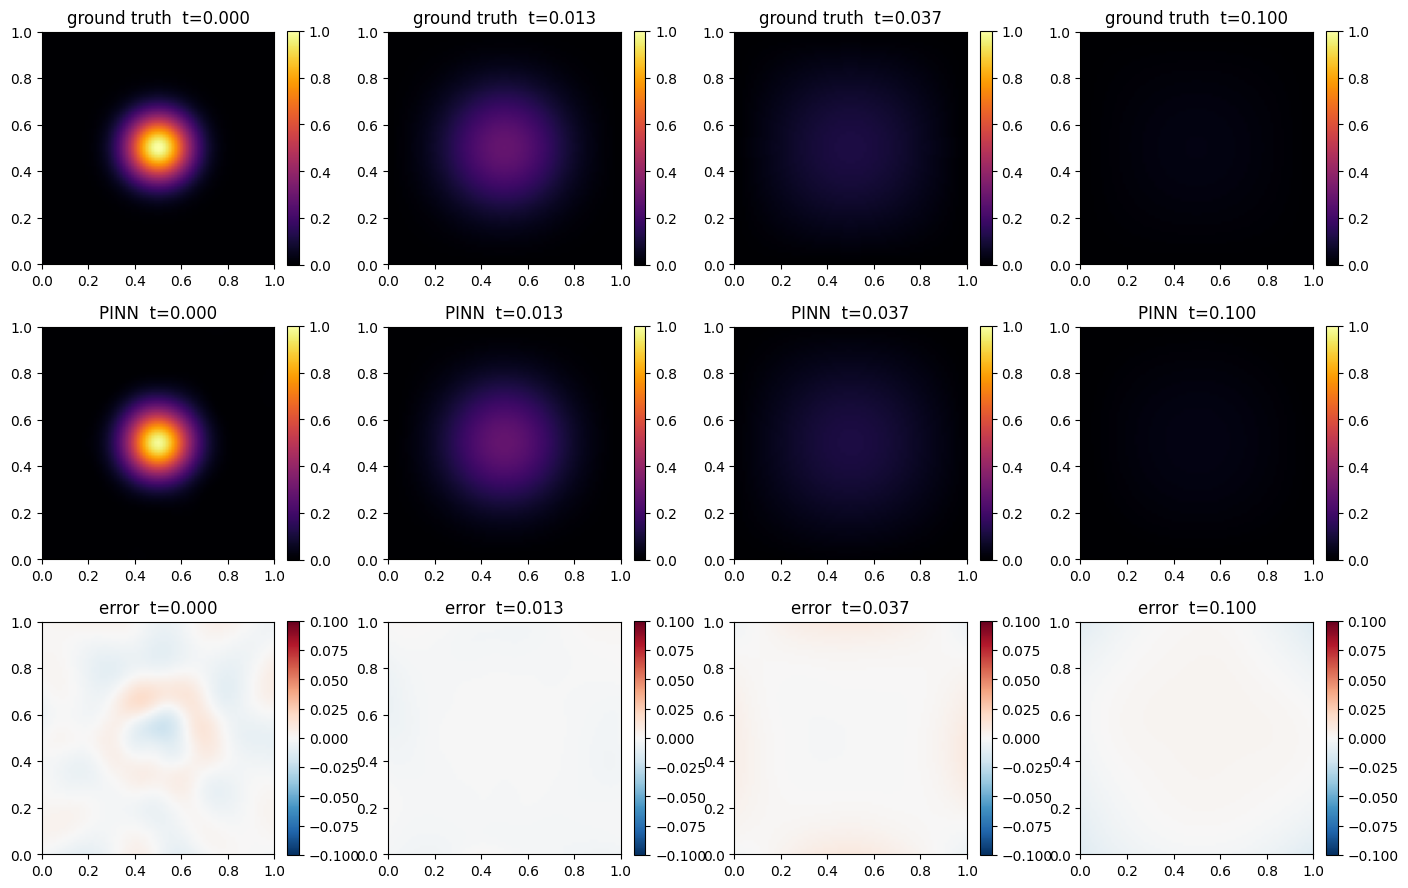

In [12]:
# side-by-side plot at a few times
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
idxs = [0, 5, 15, 40]
vmax = float(u_true.max())
for col, idx in enumerate(idxs):
    for row, (data, label) in enumerate([(u_true[idx], "ground truth"),
                                         (u_pred[idx], "PINN"),
                                         (u_pred[idx] - u_true[idx], "error")]):
        ax = axes[row, col]
        if row < 2:
            im = ax.imshow(data.T, origin="lower", vmin=0, vmax=vmax, cmap="inferno",
                           extent=[DOMAIN.x_min, DOMAIN.x_max, DOMAIN.y_min, DOMAIN.y_max])
        else:
            im = ax.imshow(data.T, origin="lower", cmap="RdBu_r",
                           vmin=-0.1 * vmax, vmax=0.1 * vmax,
                           extent=[DOMAIN.x_min, DOMAIN.x_max, DOMAIN.y_min, DOMAIN.y_max])
        ax.set_title(f"{label}  t={gt['t_snaps'][idx]:.3f}")
        plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## RL Game

In [13]:
# imports
from __future__ import annotations
import json, time
from pathlib import Path
from typing import Literal
import numpy as np
from pydantic import BaseModel, Field
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback

In [14]:
# config
class TrackConfig(BaseModel):
    n_pts: int = 400
    radius_x: float = 50.0
    radius_y: float = 30.0
    wobble: float = 6.0
    half_width: float = 4.0

class CarConfig(BaseModel):
    wheelbase: float = 2.5
    v_max: float = 25.0
    a_max: float = 6.0
    delta_max_deg: float = 30.0

class BotConfig(BaseModel):
    speed_frac: float = 0.70             # fraction of agent v_max
    lookahead_m: float = 4.0
    start_offset_m: float = 25.0         # how far ahead the bot starts

class GameConfig(BaseModel):
    n_laps: int = 3
    n_pads: int = 8
    pad_lateral_offset: float = 1.5
    pad_radius: float = 1.5
    pad_cooldown_s: float = 5.0
    boost_duration_s: float = 1.5
    boost_factor: float = 1.5
    collision_radius: float = 2.5
    soft_collision_slowdown: float = 0.7  # multiplied to agent speed on contact

class EnvConfig(BaseModel):
    dt: float = 0.05
    max_steps: int = 2400  # 120s
    w_progress: float = 1.0
    w_track: float = 0.2
    w_action: float = 0.01
    r_pad: float = 2.0
    r_overtake: float = 5.0
    r_lap: float = 5.0
    r_collision: float = 0.5
    r_crash: float = 10.0
    r_win: float = 50.0
    r_lose: float = 10.0

class TrainConfig(BaseModel):
    total_timesteps: int = 300_000
    n_envs: int = 8
    n_steps: int = 512
    batch_size: int = 128
    n_epochs: int = 10
    learning_rate: float = 3e-4
    gamma: float = 0.99
    gae_lambda: float = 0.95
    seed: int = 0

TRACK_CFG = TrackConfig()
CAR_CFG = CarConfig()
BOT_CFG = BotConfig()
GAME = GameConfig()
ENV_CFG = EnvConfig()
TRAIN = TrainConfig()

In [15]:
# build track + place pads
def make_track(cfg: TrackConfig) -> dict:
    s = np.linspace(0, 2 * np.pi, cfg.n_pts, endpoint=False)
    r = 1.0 + (cfg.wobble / max(cfg.radius_x, cfg.radius_y)) * np.sin(3 * s)
    cx = cfg.radius_x * r * np.cos(s)
    cy = cfg.radius_y * r * np.sin(s)
    dx = np.diff(cx, append=cx[0]); dy = np.diff(cy, append=cy[0])
    seg = np.sqrt(dx**2 + dy**2)
    s_arc = np.concatenate([[0.0], np.cumsum(seg)])[:-1]
    psi = np.arctan2(dy, dx)
    nx = -np.sin(psi); ny = np.cos(psi)
    inner = (cx + nx*cfg.half_width, cy + ny*cfg.half_width)
    outer = (cx - nx*cfg.half_width, cy - ny*cfg.half_width)
    total = float(s_arc[-1] + seg[-1])
    return dict(cx=cx, cy=cy, psi=psi, s=s_arc, nx=nx, ny=ny,
                total=total, ds=total/cfg.n_pts,
                inner=inner, outer=outer, half_width=cfg.half_width)

def place_pads(track: dict, n: int, lateral: float):
    idxs = np.linspace(0, len(track["cx"]), n, endpoint=False).astype(int)
    offsets = np.array([lateral if k % 2 == 0 else -lateral for k in range(n)])
    px = track["cx"][idxs] + track["nx"][idxs] * offsets
    py = track["cy"][idxs] + track["ny"][idxs] * offsets
    return px, py

TRACK = make_track(TRACK_CFG)
PAD_X, PAD_Y = place_pads(TRACK, GAME.n_pads, GAME.pad_lateral_offset)
print(f"track length: {TRACK['total']:.1f} m   pads: {GAME.n_pads}")

track length: 263.5 m   pads: 8


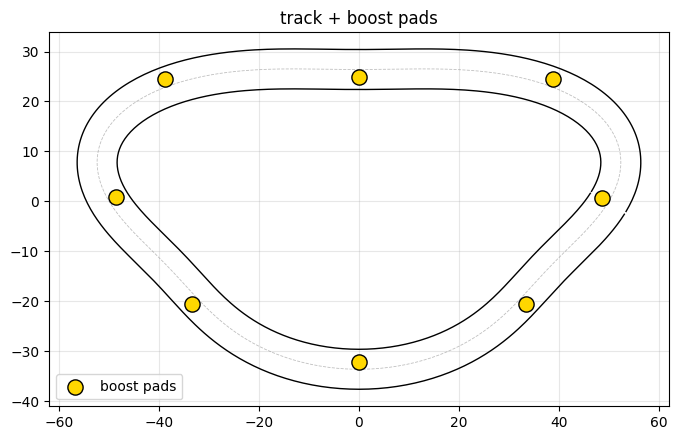

In [16]:
# preview
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(TRACK["inner"][0], TRACK["inner"][1], "k-", lw=1)
ax.plot(TRACK["outer"][0], TRACK["outer"][1], "k-", lw=1)
ax.plot(TRACK["cx"], TRACK["cy"], "--", color="gray", lw=0.6, alpha=0.5)
ax.scatter(PAD_X, PAD_Y, c="gold", s=120, edgecolor="black", zorder=5,
           label="boost pads")
ax.set_aspect("equal"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("track + boost pads"); plt.show()

In [17]:
# environment
class RaceGameEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self,
                 track: dict = TRACK,
                 pad_x: np.ndarray = PAD_X,
                 pad_y: np.ndarray = PAD_Y,
                 car: CarConfig = CAR_CFG,
                 bot: BotConfig = BOT_CFG,
                 game: GameConfig = GAME,
                 env_cfg: EnvConfig = ENV_CFG):
        super().__init__()
        self.track = track
        self.pad_x = pad_x; self.pad_y = pad_y
        self.car = car; self.bot = bot; self.game = game; self.env_cfg = env_cfg
        self.delta_max = np.deg2rad(car.delta_max_deg)
        self.bot_speed = bot.speed_frac * car.v_max
        # action: [steer, throttle]
        self.action_space = spaces.Box(-1.0, 1.0, (2,), dtype=np.float32)
        # obs (14): [v/vmax, ex/hw, eh, k1*10, k2*10, k3*10,
        #            opp_dx/30, opp_dy/30, opp_dv/vmax, lap/N,
        #            boost_active, pad_dx/30, pad_dy/30, pad_active]
        self.observation_space = spaces.Box(-np.inf, np.inf, (14,), dtype=np.float32)
        self.np_random = np.random.default_rng(0)

    # ---- helpers ----
    def _project(self, x, y):
        d2 = (self.track["cx"] - x) ** 2 + (self.track["cy"] - y) ** 2
        return int(np.argmin(d2))

    def _curvature(self, i, lookahead_m):
        N = len(self.track["cx"])
        steps = max(1, int(lookahead_m / self.track["ds"]))
        i1 = (i + steps) % N
        dpsi = np.arctan2(np.sin(self.track["psi"][i1] - self.track["psi"][i]),
                          np.cos(self.track["psi"][i1] - self.track["psi"][i]))
        return dpsi / (steps * self.track["ds"])

    def _arc_distance(self, i_from, i_to):
        N = len(self.track["cx"])
        di = (i_to - i_from) % N
        if di > N // 2: di -= N
        return di * self.track["ds"]

    def _bot_step(self):
        x, y, psi, v = self.bot_state
        i = self._project(x, y)
        N = len(self.track["cx"])
        steps = max(1, int(self.bot.lookahead_m / self.track["ds"]))
        ti = (i + steps) % N
        target_heading = np.arctan2(self.track["cy"][ti] - y, self.track["cx"][ti] - x)
        eh = np.arctan2(np.sin(target_heading - psi), np.cos(target_heading - psi))
        delta = float(np.clip(eh * 1.5, -self.delta_max, self.delta_max))
        a = float(np.clip((self.bot_speed - v) * 1.0, -self.car.a_max, self.car.a_max))
        x += v * np.cos(psi) * self.env_cfg.dt
        y += v * np.sin(psi) * self.env_cfg.dt
        psi += (v / self.car.wheelbase) * np.tan(delta) * self.env_cfg.dt
        v = float(np.clip(v + a * self.env_cfg.dt, 0.0, self.car.v_max))
        self.bot_state = np.array([x, y, psi, v])
        # bot lap progress
        if not hasattr(self, "_bot_last_i"): self._bot_last_i = i
        ds = self._arc_distance(self._bot_last_i, i)
        self._bot_arc += ds
        self._bot_last_i = i
        if self._bot_arc >= self.track["total"]:
            self._bot_arc -= self.track["total"]
            self.bot_lap += 1

    def _obs(self):
        x, y, psi, v = self.state
        i = self._project(x, y)
        psi_c = self.track["psi"][i]
        ex = (-np.sin(psi_c)) * (x - self.track["cx"][i]) + (np.cos(psi_c)) * (y - self.track["cy"][i])
        eh = np.arctan2(np.sin(psi - psi_c), np.cos(psi - psi_c))
        k1 = self._curvature(i, 4.0)
        k2 = self._curvature(i, 10.0)
        k3 = self._curvature(i, 20.0)

        # opponent in agent frame
        bx, by, _, bv = self.bot_state
        cs, sn = np.cos(-psi), np.sin(-psi)
        ox = cs * (bx - x) - sn * (by - y)
        oy = sn * (bx - x) + cs * (by - y)
        odv = bv - v

        # nearest active pad (in agent frame)
        active_mask = self.pad_cooldowns <= 0
        if active_mask.any():
            dxs = self.pad_x[active_mask] - x
            dys = self.pad_y[active_mask] - y
            k = int(np.argmin(dxs**2 + dys**2))
            actual = np.where(active_mask)[0][k]
            pdx = self.pad_x[actual] - x
            pdy = self.pad_y[actual] - y
            pcs = cs * pdx - sn * pdy
            psn = sn * pdx + cs * pdy
            pad_active = 1.0
        else:
            pcs, psn, pad_active = 50.0, 0.0, 0.0

        return np.array([v / self.car.v_max, ex / self.track["half_width"], eh,
                         10.0 * k1, 10.0 * k2, 10.0 * k3,
                         ox / 30.0, oy / 30.0, odv / self.car.v_max,
                         self.lap / self.game.n_laps,
                         float(self.boost_remaining > 0),
                         pcs / 30.0, psn / 30.0, pad_active], dtype=np.float32), i, ex

    def reset(self, seed: int | None = None, options=None):
        if seed is not None:
            self.np_random = np.random.default_rng(seed)
        i0 = 0
        x0 = self.track["cx"][i0] + self.np_random.normal(0, 0.2)
        y0 = self.track["cy"][i0] + self.np_random.normal(0, 0.2)
        psi0 = float(self.track["psi"][i0])
        v0 = float(self.np_random.uniform(2.0, 5.0))
        self.state = np.array([x0, y0, psi0, v0])

        # bot starts ahead by start_offset_m along the centerline
        offset_steps = int(self.bot.start_offset_m / self.track["ds"])
        bi = (i0 + offset_steps) % len(self.track["cx"])
        self.bot_state = np.array([self.track["cx"][bi], self.track["cy"][bi],
                                   self.track["psi"][bi], self.bot_speed * 0.6])
        self._bot_last_i = bi
        self._bot_arc = 0.0
        self.bot_lap = 0

        self.pad_cooldowns = np.zeros(self.game.n_pads)
        self.boost_remaining = 0.0
        self.lap = 0
        self.t = 0
        self._last_i = i0
        self._lap_arc = 0.0
        self._last_lap_step = 0
        self._was_behind = True
        self.lap_times: list[float] = []
        # event log for the viewer
        self.events: list[dict] = []
        obs, _, _ = self._obs()
        return obs, {}

    def step(self, action):
        action = np.clip(action, -1.0, 1.0).astype(np.float32)
        delta = float(action[0]) * self.delta_max
        a = float(action[1]) * self.car.a_max
        x, y, psi, v = self.state
        dt = self.env_cfg.dt

        # boost-aware speed cap
        v_eff_max = self.car.v_max * (self.game.boost_factor if self.boost_remaining > 0 else 1.0)
        x += v * np.cos(psi) * dt
        y += v * np.sin(psi) * dt
        psi += (v / self.car.wheelbase) * np.tan(delta) * dt
        v = float(np.clip(v + a * dt, 0.0, v_eff_max))
        self.state = np.array([x, y, psi, v])
        self._bot_step()

        # tick timers
        self.boost_remaining = max(0.0, self.boost_remaining - dt)
        self.pad_cooldowns = np.maximum(0.0, self.pad_cooldowns - dt)
        self.t += 1

        # pad collection
        pad_reward = 0.0
        for k in range(self.game.n_pads):
            if self.pad_cooldowns[k] <= 0:
                if (self.pad_x[k] - x) ** 2 + (self.pad_y[k] - y) ** 2 < self.game.pad_radius ** 2:
                    self.pad_cooldowns[k] = self.game.pad_cooldown_s
                    self.boost_remaining = self.game.boost_duration_s
                    pad_reward += 1.0
                    self.events.append({"t": self.t, "kind": "pad", "idx": int(k)})

        # arc progress + lap detection
        obs, i, ex = self._obs()
        ds = self._arc_distance(self._last_i, i)
        self._last_i = i
        self._lap_arc += ds
        new_lap = False
        if self._lap_arc >= self.track["total"]:
            self._lap_arc -= self.track["total"]
            self.lap += 1
            self.lap_times.append((self.t - self._last_lap_step) * dt)
            self._last_lap_step = self.t
            new_lap = True
            self.events.append({"t": self.t, "kind": "lap", "lap": int(self.lap),
                                "lap_time": float(self.lap_times[-1])})

        # overtake detection
        bi = self._project(self.bot_state[0], self.bot_state[1])
        gap = self._arc_distance(i, bi)
        is_behind = gap > 0
        overtake_bonus = 0.0
        if self._was_behind and not is_behind:
            overtake_bonus = self.env_cfg.r_overtake
            self.events.append({"t": self.t, "kind": "overtake"})
        self._was_behind = is_behind

        # soft collision
        coll_pen = 0.0
        if (self.bot_state[0] - x) ** 2 + (self.bot_state[1] - y) ** 2 < self.game.collision_radius ** 2:
            v *= self.game.soft_collision_slowdown
            self.state[3] = v
            coll_pen = self.env_cfg.r_collision

        # crash off-track
        terminated = False; crash_pen = 0.0
        if abs(ex) > self.track["half_width"]:
            terminated = True
            crash_pen = self.env_cfg.r_crash
            self.events.append({"t": self.t, "kind": "crash"})

        # finish
        finish_bonus = 0.0
        won = False
        if not terminated and self.lap >= self.game.n_laps:
            terminated = True
            won = (self.lap > self.bot_lap) or (self.lap == self.bot_lap and not is_behind)
            finish_bonus = self.env_cfg.r_win if won else self.env_cfg.r_lose
            self.events.append({"t": self.t, "kind": "finish", "won": bool(won)})

        truncated = (self.t >= self.env_cfg.max_steps) and not terminated

        reward = (self.env_cfg.w_progress * ds
                  - self.env_cfg.w_track * (ex / self.track["half_width"]) ** 2
                  - self.env_cfg.w_action * float(action[0]) ** 2
                  + self.env_cfg.r_pad * pad_reward
                  + overtake_bonus
                  - coll_pen
                  - crash_pen
                  + (self.env_cfg.r_lap if new_lap and self.lap < self.game.n_laps else 0.0)
                  + finish_bonus)

        info = {"i": i, "ex": ex, "v": v, "lap": self.lap, "bot_lap": self.bot_lap,
                "boost": self.boost_remaining > 0, "gap": gap,
                "behind": is_behind, "lap_times": list(self.lap_times),
                "won": won}
        return obs, float(reward), terminated, truncated, info

In [18]:
# sanity-check
env = RaceGameEnv()
obs, _ = env.reset(seed=0)
print(f"obs dim: {obs.shape}")
total = 0.0
for _ in range(60):
    obs, r, term, trunc, info = env.step(np.array([0.0, 0.7], dtype=np.float32))
    total += r
    if term or trunc: break
print(f"reward (straight & gas): {total:.2f}  v={info['v']:.1f}  gap={info['gap']:.1f}  "
      f"behind={info['behind']}  boost={info['boost']}")

obs dim: (14,)
reward (straight & gas): 1.95  v=10.5  gap=34.9  behind=True  boost=False


In [19]:
# logging callback
class GameLogger(BaseCallback):
    def __init__(self):
        super().__init__()
        self.history: list[dict] = []
    def _on_step(self):
        for info in self.locals.get("infos", []):
            ep = info.get("episode")
            if ep is not None:
                self.history.append({
                    "t": self.num_timesteps,
                    "r": float(ep["r"]),
                    "l": int(ep["l"]),
                    "won": bool(info.get("won", False)),
                    "lap": int(info.get("lap", 0)),
                })
        return True

In [20]:
# train
def make_env(seed: int):
    def _f():
        e = RaceGameEnv(); e.reset(seed=seed); return e
    return _f

vec = DummyVecEnv([make_env(TRAIN.seed + k) for k in range(TRAIN.n_envs)])
model = PPO("MlpPolicy", vec, verbose=0,
            n_steps=TRAIN.n_steps, batch_size=TRAIN.batch_size,
            n_epochs=TRAIN.n_epochs, learning_rate=TRAIN.learning_rate,
            gamma=TRAIN.gamma, gae_lambda=TRAIN.gae_lambda, seed=TRAIN.seed)
logger = GameLogger()
t0 = time.time()
model.learn(total_timesteps=TRAIN.total_timesteps, callback=logger)
print(f"trained in {time.time()-t0:.1f}s, episodes seen: {len(logger.history)}")

trained in 40.1s, episodes seen: 0


In [21]:
# learning curves
if not logger.history:
    print("no completed episodes yet — train longer to see curves")
else:
    ts = np.array([h["t"] for h in logger.history])
    rs = np.array([h["r"] for h in logger.history])
    won = np.array([h["won"] for h in logger.history], dtype=float)
    laps = np.array([h["lap"] for h in logger.history], dtype=float)
    w = max(1, len(rs) // 50)
    def roll(x): return np.convolve(x, np.ones(w)/w, mode="valid")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(ts, rs, alpha=0.2); axes[0].plot(ts[w-1:], roll(rs))
    axes[0].set_title("episode return"); axes[0].grid(alpha=0.3)
    axes[1].plot(ts[w-1:], roll(won)); axes[1].set_ylim(-0.05, 1.05)
    axes[1].set_title(f"win rate (rolling, w={w})"); axes[1].grid(alpha=0.3)
    axes[2].plot(ts[w-1:], roll(laps)); axes[2].axhline(GAME.n_laps, ls="--", c="r", alpha=0.5)
    axes[2].set_title("laps completed (rolling)"); axes[2].grid(alpha=0.3)
    for a in axes: a.set_xlabel("timesteps")
    plt.tight_layout(); plt.show()

no completed episodes yet — train longer to see curves


In [22]:
# rollout collection
def rollout(model, env: RaceGameEnv, seed: int) -> dict:
    obs, _ = env.reset(seed=seed)
    xs, ys, psis, vs, steers, throttles, boosts, gaps = [], [], [], [], [], [], [], []
    bxs, bys, bpsis, bvs = [], [], [], []
    pad_states_log = []  # cooldowns each step
    R = 0.0
    for _ in range(env.env_cfg.max_steps):
        a, _ = model.predict(obs, deterministic=True)
        obs, r, term, trunc, info = env.step(a)
        x, y, psi, v = env.state; bx, by, bpsi, bv = env.bot_state
        xs.append(x); ys.append(y); psis.append(psi); vs.append(v)
        bxs.append(bx); bys.append(by); bpsis.append(bpsi); bvs.append(bv)
        steers.append(float(a[0])); throttles.append(float(a[1]))
        boosts.append(env.boost_remaining > 0)
        gaps.append(info["gap"])
        pad_states_log.append(env.pad_cooldowns.copy())
        R += r
        if term or trunc: break
    return dict(x=np.array(xs), y=np.array(ys), psi=np.array(psis), v=np.array(vs),
                bx=np.array(bxs), by=np.array(bys), bpsi=np.array(bpsis), bv=np.array(bvs),
                steer=np.array(steers), throttle=np.array(throttles),
                boost=np.array(boosts), gap=np.array(gaps),
                pad_cooldowns=np.array(pad_states_log),
                R=R, length=len(xs), lap_times=info["lap_times"],
                won=info.get("won", False), final_lap=info["lap"],
                events=list(env.events))

eval_env = RaceGameEnv()
rollouts = [rollout(model, eval_env, seed=500 + k) for k in range(4)]
for k, r in enumerate(rollouts):
    times_str = ", ".join(f"{t:.2f}s" for t in r["lap_times"])
    print(f"ep{k}: return={r['R']:.1f}  laps={r['final_lap']}  won={r['won']}  "
          f"laps=[{times_str}]")

ep0: return=858.6  laps=3  won=True  laps=[14.50s, 15.05s, 15.15s]
ep1: return=862.3  laps=3  won=True  laps=[14.50s, 15.05s, 15.15s]
ep2: return=858.7  laps=3  won=True  laps=[14.50s, 15.30s, 14.95s]
ep3: return=860.9  laps=3  won=True  laps=[14.70s, 15.05s, 15.00s]


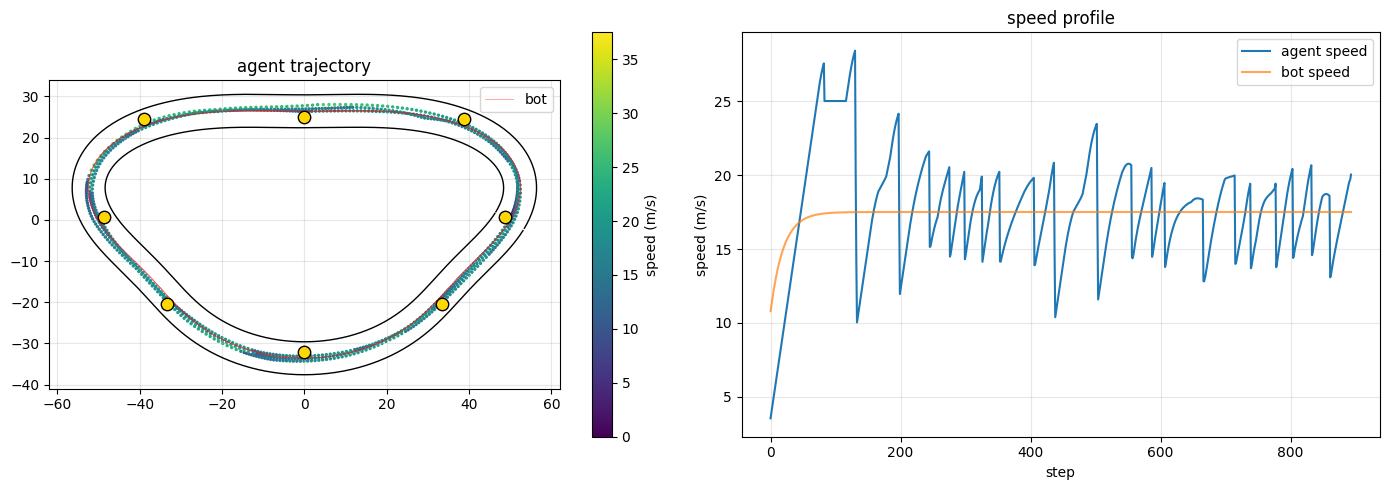

In [31]:
# trajectory + speed plot
best = max(rollouts, key=lambda r: r["R"])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(TRACK["inner"][0], TRACK["inner"][1], "k", lw=1)
ax.plot(TRACK["outer"][0], TRACK["outer"][1], "k", lw=1)
ax.plot(TRACK["cx"], TRACK["cy"], "--", color="gray", lw=0.5, alpha=0.5)
ax.scatter(PAD_X, PAD_Y, c="gold", s=80, edgecolor="black", zorder=5)
sc = ax.scatter(best["x"], best["y"], c=best["v"], cmap="viridis", s=2,
                vmin=0, vmax=CAR_CFG.v_max * GAME.boost_factor)
ax.plot(best["bx"], best["by"], "r-", lw=0.5, alpha=0.5, label="bot")
ax.set_aspect("equal"); ax.set_title("agent trajectory");
ax.legend(); ax.grid(alpha=0.3)
plt.colorbar(sc, ax=ax, label="speed (m/s)")

ax2 = axes[1]
ax2.plot(best["v"], label="agent speed")
ax2.plot(best["bv"], label="bot speed", alpha=0.7)
ax2.set_xlabel("step"); ax2.set_ylabel("speed (m/s)")
ax2.legend(); ax2.grid(alpha=0.3); ax2.set_title("speed profile")
plt.tight_layout(); plt.show()

In [26]:
# export
OUT_DIR = Path("/Users/daryaguettler/NMM/notebooks/hw12/RL_viz")
OUT_DIR.mkdir(exist_ok=True)
best = max(rollouts, key=lambda r: r["R"])

# Downsample pad cooldown log to a binary "active" stream per step (smaller payload)
pad_active_log = (best["pad_cooldowns"] <= 0.0).astype(np.uint8).tolist()

payload = {
    "track": {
        "inner_x": TRACK["inner"][0].tolist(),
        "inner_y": TRACK["inner"][1].tolist(),
        "outer_x": TRACK["outer"][0].tolist(),
        "outer_y": TRACK["outer"][1].tolist(),
        "center_x": TRACK["cx"].tolist(),
        "center_y": TRACK["cy"].tolist(),
        "half_width": TRACK["half_width"],
    },
    "pads": {"x": PAD_X.tolist(), "y": PAD_Y.tolist(),
             "active_log": pad_active_log},
    "car": {"wheelbase": CAR_CFG.wheelbase, "v_max": CAR_CFG.v_max,
            "v_max_boost": CAR_CFG.v_max * GAME.boost_factor},
    "agent": {"x": best["x"].tolist(), "y": best["y"].tolist(),
              "psi": best["psi"].tolist(), "v": best["v"].tolist(),
              "steer": best["steer"].tolist(), "throttle": best["throttle"].tolist(),
              "boost": [bool(b) for b in best["boost"].tolist()]},
    "bot": {"x": best["bx"].tolist(), "y": best["by"].tolist(),
            "psi": best["bpsi"].tolist(), "v": best["bv"].tolist()},
    "events": best["events"],
    "summary": {"return": float(best["R"]),
                "length": int(best["length"]),
                "lap_times": [float(t) for t in best["lap_times"]],
                "won": bool(best["won"]),
                "n_laps": GAME.n_laps,
                "dt": ENV_CFG.dt},
}
out_json = OUT_DIR / "rollout.json"
out_json.write_text(json.dumps(payload))
print("wrote", out_json, "size:", out_json.stat().st_size // 1024, "KB")

wrote /Users/daryaguettler/NMM/notebooks/hw12/RL_viz/rollout.json size: 247 KB


In [29]:
# write the HTML viewer
template = r'''<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8" />
<title>Racecar RL — game edition</title>
<style>
  :root { color-scheme: dark; }
  body { margin: 0; font-family: -apple-system, system-ui, sans-serif;
         background: #0b0d10; color: #e7e7e7; }
  header { padding: 14px 20px; border-bottom: 1px solid #222; }
  header h1 { margin: 0; font-size: 16px; font-weight: 600; }
  header p  { margin: 4px 0 0; font-size: 12px; color: #9aa0a6; }
  #stage { position: relative; height: calc(100vh - 230px); }
  .hud { position: absolute; padding: 10px 14px; background: rgba(0,0,0,0.6);
         border-radius: 6px; font-size: 13px; font-variant-numeric: tabular-nums;
         border: 1px solid #1f2228; }
  #hud-status { top: 12px; left: 14px; }
  #hud-laps   { top: 12px; right: 14px; min-width: 180px; }
  #hud-events { bottom: 12px; left: 14px; max-width: 320px; max-height: 130px;
                overflow: hidden; }
  .hud .label { color: #9aa0a6; }
  .pos-1st { color: #4ade80; font-weight: 700; }
  .pos-2nd { color: #fbbf24; font-weight: 700; }
  .boost-bar { display: inline-block; vertical-align: middle; width: 100px; height: 8px;
               background: #1a1d22; border-radius: 4px; overflow: hidden; margin-left: 6px;
               border: 1px solid #2a2f36; }
  .boost-bar > div { height: 100%; background: linear-gradient(90deg, #ffd166, #ef476f);
                     width: 0%; transition: width 0.05s linear; }
  .lap-row { display: flex; justify-content: space-between; gap: 12px; padding: 2px 0; }
  .lap-row.best { color: #ffd166; }
  .ev { padding: 2px 0; opacity: 0.85; }
  .ev.lap { color: #87cefa; }
  .ev.pad { color: #ffd166; }
  .ev.overtake { color: #4ade80; }
  .ev.crash, .ev.finish { color: #ef476f; font-weight: 600; }
  .controls { display: flex; align-items: center; gap: 14px; padding: 12px 20px;
              border-top: 1px solid #222; }
  button { background: #1a1d22; color: #e7e7e7; border: 1px solid #2a2f36;
           padding: 6px 14px; border-radius: 4px; cursor: pointer; font: inherit; }
  button:hover { background: #232730; }
  input[type=range] { flex: 1; }
  .readout { font-size: 12px; color: #9aa0a6; min-width: 220px; text-align: right;
             font-variant-numeric: tabular-nums; }
  label { font-size: 12px; color: #9aa0a6; }
</style>
</head>
<body>
<header>
  <h1>Racecar RL — 3-lap race vs. AI bot, with boost pads</h1>
  <p>The trained PPO policy (red) races a scripted pure-pursuit bot (blue) over <span id="hdr-laps">3</span> laps. Boost pads (gold) give a 1.5× speed boost for 1.5 s, then cool down for 5 s.</p>
</header>

<div id="stage">
  <div class="hud" id="hud-status">
    <div><span class="label">position</span> <b id="pos">—</b>  <span class="label">gap</span> <b id="gap">0.0</b> m</div>
    <div><span class="label">speed</span> <b id="spd">0.0</b> m/s</div>
    <div><span class="label">boost</span> <span class="boost-bar"><div id="boost-bar"></div></span></div>
  </div>
  <div class="hud" id="hud-laps">
    <div style="font-weight:600;margin-bottom:4px">lap times</div>
    <div id="lap-list"></div>
  </div>
  <div class="hud" id="hud-events">
    <div style="font-weight:600;margin-bottom:4px">events</div>
    <div id="event-list"></div>
  </div>
</div>

<div class="controls">
  <button id="play">Pause</button>
  <button id="restart">Restart</button>
  <input id="scrub" type="range" min="0" max="0" step="1" value="0" />
  <label><input type="checkbox" id="follow" checked /> chase cam</label>
  <div class="readout" id="readout">step 0</div>
</div>

<script>const DATA = __PAYLOAD__;</script>
<script type="importmap">
{ "imports": { "three": "https://unpkg.com/three@0.160.0/build/three.module.js",
               "three/addons/": "https://unpkg.com/three@0.160.0/examples/jsm/" } }
</script>
<script type="module">
import * as THREE from 'three';
import { OrbitControls } from 'three/addons/controls/OrbitControls.js';

document.getElementById('hdr-laps').textContent = String(DATA.summary.n_laps);

const stage = document.getElementById('stage');
const renderer = new THREE.WebGLRenderer({ antialias: true });
renderer.setPixelRatio(window.devicePixelRatio);
stage.appendChild(renderer.domElement);
const scene = new THREE.Scene();
scene.background = new THREE.Color(0x0b0d10);
const camera = new THREE.PerspectiveCamera(45, 1, 0.1, 5000);
camera.position.set(0, 130, 100);
const controls = new OrbitControls(camera, renderer.domElement);
controls.target.set(0, 0, 0); controls.enableDamping = true;

scene.add(new THREE.AmbientLight(0xffffff, 0.6));
const dirL = new THREE.DirectionalLight(0xffffff, 0.8);
dirL.position.set(40, 100, 40); scene.add(dirL);

// ---- track surface ----
function buildTrack() {
  const N = DATA.track.center_x.length;
  const positions = new Float32Array(N * 2 * 3);
  for (let i = 0; i < N; i++) {
    positions[6*i+0] = DATA.track.inner_x[i];
    positions[6*i+1] = 0.0;
    positions[6*i+2] = DATA.track.inner_y[i];
    positions[6*i+3] = DATA.track.outer_x[i];
    positions[6*i+4] = 0.0;
    positions[6*i+5] = DATA.track.outer_y[i];
  }
  const indices = [];
  for (let i = 0; i < N; i++) {
    const j = (i + 1) % N;
    const a = 2*i, b = 2*i+1, c = 2*j, d = 2*j+1;
    indices.push(a, b, d, a, d, c);
  }
  const g = new THREE.BufferGeometry();
  g.setAttribute('position', new THREE.BufferAttribute(positions, 3));
  g.setIndex(indices); g.computeVertexNormals();
  return new THREE.Mesh(g, new THREE.MeshStandardMaterial({ color: 0x2a2d33, roughness: 0.95 }));
}
scene.add(buildTrack());

function lineFrom(xs, ys, color, y=0.05) {
  const pts = xs.map((x, i) => new THREE.Vector3(x, y, ys[i]));
  pts.push(pts[0].clone());
  return new THREE.Line(new THREE.BufferGeometry().setFromPoints(pts),
                        new THREE.LineBasicMaterial({ color }));
}
scene.add(lineFrom(DATA.track.inner_x, DATA.track.inner_y, 0xffffff));
scene.add(lineFrom(DATA.track.outer_x, DATA.track.outer_y, 0xffffff));

// dashed centerline
{
  const pts = DATA.track.center_x.map((x, i) =>
    new THREE.Vector3(x, 0.06, DATA.track.center_y[i]));
  pts.push(pts[0].clone());
  const m = new THREE.LineDashedMaterial({ color: 0xf2c14e, dashSize: 1.2, gapSize: 1.2, opacity: 0.7, transparent: true });
  const ln = new THREE.Line(new THREE.BufferGeometry().setFromPoints(pts), m);
  ln.computeLineDistances(); scene.add(ln);
}

// start/finish line marker
{
  const i0 = 0;
  const cx = DATA.track.center_x[i0], cy = DATA.track.center_y[i0];
  const ix = DATA.track.inner_x[i0], iy = DATA.track.inner_y[i0];
  const ox = DATA.track.outer_x[i0], oy = DATA.track.outer_y[i0];
  const pts = [new THREE.Vector3(ix, 0.08, iy), new THREE.Vector3(ox, 0.08, oy)];
  const m = new THREE.LineBasicMaterial({ color: 0xffffff, linewidth: 2 });
  scene.add(new THREE.Line(new THREE.BufferGeometry().setFromPoints(pts), m));
}

// ---- boost pads ----
const padMeshes = [];
const padHaloes = [];
for (let k = 0; k < DATA.pads.x.length; k++) {
  const pad = new THREE.Mesh(
    new THREE.CylinderGeometry(1.2, 1.2, 0.15, 24),
    new THREE.MeshStandardMaterial({ color: 0xffd166, emissive: 0x553300,
                                     emissiveIntensity: 0.4, roughness: 0.5 }));
  pad.position.set(DATA.pads.x[k], 0.08, DATA.pads.y[k]);
  scene.add(pad); padMeshes.push(pad);
  const halo = new THREE.Mesh(
    new THREE.RingGeometry(1.4, 2.0, 32),
    new THREE.MeshBasicMaterial({ color: 0xffd166, side: THREE.DoubleSide,
                                  transparent: true, opacity: 0.4 }));
  halo.rotation.x = -Math.PI / 2; halo.position.set(DATA.pads.x[k], 0.09, DATA.pads.y[k]);
  scene.add(halo); padHaloes.push(halo);
}

// ---- agent trajectory ribbon (color-coded by speed) ----
{
  const A = DATA.agent;
  const pts = A.x.map((x, i) => new THREE.Vector3(x, 0.07, A.y[i]));
  const colors = [];
  const vmax = DATA.car.v_max_boost;
  for (let i = 0; i < A.v.length; i++) {
    const f = Math.min(1, A.v[i] / vmax);
    colors.push(f, 1 - f, 0.2);
  }
  const g = new THREE.BufferGeometry().setFromPoints(pts);
  g.setAttribute('color', new THREE.Float32BufferAttribute(colors, 3));
  scene.add(new THREE.Line(g, new THREE.LineBasicMaterial({ vertexColors: true, transparent: true, opacity: 0.55 })));
}

// ---- car factory ----
function buildCar(bodyColor) {
  const g = new THREE.Group();
  const body = new THREE.Mesh(
    new THREE.BoxGeometry(2.0, 0.6, 4.2),
    new THREE.MeshStandardMaterial({ color: bodyColor, roughness: 0.4, metalness: 0.2 }));
  body.position.y = 0.6; g.add(body);
  const cabin = new THREE.Mesh(
    new THREE.BoxGeometry(1.6, 0.5, 1.8),
    new THREE.MeshStandardMaterial({ color: 0x222222 }));
  cabin.position.set(0, 1.15, -0.2); g.add(cabin);
  const wg = new THREE.CylinderGeometry(0.35, 0.35, 0.3, 18); wg.rotateZ(Math.PI / 2);
  const wm = new THREE.MeshStandardMaterial({ color: 0x111111 });
  for (const [wx, wz] of [[-1.0, 1.5], [1.0, 1.5], [-1.0, -1.5], [1.0, -1.5]]) {
    const w = new THREE.Mesh(wg, wm); w.position.set(wx, 0.35, wz); g.add(w);
  }
  return g;
}
const agentCar = buildCar(0xff5252);
const botCar   = buildCar(0x3aa0ff);
scene.add(agentCar); scene.add(botCar);

// boost flame on agent
const flame = new THREE.Mesh(
  new THREE.ConeGeometry(0.5, 1.5, 12),
  new THREE.MeshBasicMaterial({ color: 0xffd166, transparent: true, opacity: 0.85 }));
flame.rotation.x = Math.PI / 2;
flame.position.set(0, 0.6, 2.7);
agentCar.add(flame);
flame.visible = false;

// ---- HUD setup ----
const hudPos = document.getElementById('pos');
const hudGap = document.getElementById('gap');
const hudSpd = document.getElementById('spd');
const hudBoost = document.getElementById('boost-bar');
const lapList = document.getElementById('lap-list');
const eventList = document.getElementById('event-list');

function renderLapList() {
  const times = DATA.summary.lap_times;
  const best = times.length ? Math.min(...times) : null;
  lapList.innerHTML = times.map((t, i) =>
    `<div class="lap-row${t === best ? ' best' : ''}"><span>lap ${i+1}</span><span>${t.toFixed(2)} s</span></div>`
  ).join('');
}
renderLapList();

function renderEvents(curStep) {
  const upTo = DATA.events.filter(e => e.t <= curStep).slice(-5);
  eventList.innerHTML = upTo.map(e => {
    if (e.kind === 'lap')      return `<div class="ev lap">lap ${e.lap}: ${e.lap_time.toFixed(2)} s</div>`;
    if (e.kind === 'pad')      return `<div class="ev pad">+ boost (pad ${e.idx})</div>`;
    if (e.kind === 'overtake') return `<div class="ev overtake">overtake!</div>`;
    if (e.kind === 'crash')    return `<div class="ev crash">crash</div>`;
    if (e.kind === 'finish')   return `<div class="ev finish">${e.won ? 'WIN!' : 'finish (2nd)'}</div>`;
    return '';
  }).join('');
}

// ---- playback ----
const N = DATA.agent.x.length;
const scrub = document.getElementById('scrub');
const playBtn = document.getElementById('play');
const restartBtn = document.getElementById('restart');
const readout = document.getElementById('readout');
const followCB = document.getElementById('follow');
scrub.max = String(N - 1);
let frame = 0;
let playing = true;

function setFrame(i) {
  frame = i; scrub.value = String(i);
  // agent
  agentCar.position.set(DATA.agent.x[i], 0.0, DATA.agent.y[i]);
  agentCar.rotation.y = -DATA.agent.psi[i] + Math.PI / 2;
  // bot
  botCar.position.set(DATA.bot.x[i], 0.0, DATA.bot.y[i]);
  botCar.rotation.y = -DATA.bot.psi[i] + Math.PI / 2;
  // pad active visuals
  const padRow = DATA.pads.active_log[i];
  for (let k = 0; k < padMeshes.length; k++) {
    const active = padRow[k] === 1;
    padMeshes[k].material.emissiveIntensity = active ? 0.9 : 0.05;
    padMeshes[k].material.color.setHex(active ? 0xffd166 : 0x665533);
    padHaloes[k].material.opacity = active ? 0.55 : 0.0;
  }
  // boost flame
  flame.visible = DATA.agent.boost[i];
  // HUD
  hudSpd.textContent = DATA.agent.v[i].toFixed(1);
  // estimate boost remaining: count consecutive boost frames ahead
  let boostFrames = 0;
  for (let j = i; j < N && DATA.agent.boost[j]; j++) boostFrames++;
  const boostPct = Math.min(100, (boostFrames * DATA.summary.dt / 1.5) * 100);
  hudBoost.style.width = `${DATA.agent.boost[i] ? boostPct : 0}%`;
  // gap & position: agent in 1st if it was the closer one to finish
  // compute gap as 2D distance of bot vs agent in *opponent ahead* sense
  const dx = DATA.bot.x[i] - DATA.agent.x[i];
  const dz = DATA.bot.y[i] - DATA.agent.y[i];
  const gap2d = Math.sqrt(dx*dx + dz*dz);
  hudGap.textContent = gap2d.toFixed(1);
  // 1st/2nd: based on who's done more "progress" — approximate via cumulative path length
  // simpler proxy: compare arc index of agent vs bot (we don't have direct arc, use closest center pt)
  // For HUD only, just say "1st" if agent's traveled further than bot up to this frame.
  // We'll precompute cumulative path length at startup.
  const pos = (cumAgent[i] >= cumBot[i]) ? '1st' : '2nd';
  hudPos.textContent = pos;
  hudPos.className = pos === '1st' ? 'pos-1st' : 'pos-2nd';

  renderEvents(i);
  readout.textContent = `step ${i}/${N - 1}  ·  t=${(i * DATA.summary.dt).toFixed(2)}s`;

  if (followCB.checked) {
    controls.target.set(DATA.agent.x[i], 0, DATA.agent.y[i]);
  }
}

// precompute cumulative travel (for position HUD)
const cumAgent = new Float32Array(N), cumBot = new Float32Array(N);
for (let i = 1; i < N; i++) {
  const da = Math.hypot(DATA.agent.x[i]-DATA.agent.x[i-1], DATA.agent.y[i]-DATA.agent.y[i-1]);
  const db = Math.hypot(DATA.bot.x[i]-DATA.bot.x[i-1],     DATA.bot.y[i]-DATA.bot.y[i-1]);
  cumAgent[i] = cumAgent[i-1] + da;
  cumBot[i]   = cumBot[i-1]   + db;
}

scrub.addEventListener('input', e => {
  playing = false; playBtn.textContent = 'Play';
  setFrame(parseInt(e.target.value, 10));
});
playBtn.addEventListener('click', () => {
  playing = !playing; playBtn.textContent = playing ? 'Pause' : 'Play';
});
restartBtn.addEventListener('click', () => {
  setFrame(0); playing = true; playBtn.textContent = 'Pause';
});

let last = performance.now(), accum = 0;
const MS_PER_FRAME = DATA.summary.dt * 1000;
function loop(now) {
  const dt = now - last; last = now;
  if (playing) {
    accum += dt;
    while (accum >= MS_PER_FRAME) {
      accum -= MS_PER_FRAME;
      setFrame((frame + 1) % N);
    }
  }
  controls.update();
  renderer.render(scene, camera);
  requestAnimationFrame(loop);
}

function resize() {
  const w = stage.clientWidth, h = stage.clientHeight;
  renderer.setSize(w, h, false);
  camera.aspect = w / h; camera.updateProjectionMatrix();
}
new ResizeObserver(resize).observe(stage);
resize();
setFrame(0);
requestAnimationFrame(loop);
</script>
</body>
</html>
'''
html = template.replace("__PAYLOAD__", json.dumps(payload))
out_path = OUT_DIR / "race_game_viewer.html"
out_path.write_text(html)
print("wrote", out_path, "size:", out_path.stat().st_size // 1024, "KB")
print("Open this file in a browser to watch the race.")

wrote /Users/daryaguettler/NMM/notebooks/hw12/RL_viz/race_game_viewer.html size: 261 KB
Open this file in a browser to watch the race.
